In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

dtypes = {
    'user_id':       'int32',
    'item_id':       'int32',
    'category_id':   'int32',
    'behavior_type': 'category',
    'datetime' : 'string'
}
col_names = ['user_id', 'item_id', 'category_id','behavior_type', 'datetime']
data_path = Path.cwd().parent / 'UserBehavior_cleaning.csv'
chunks = []
chunk_size = 5_000_000

for chunk in pd.read_csv(
    data_path,
    header = 0,
    usecols=col_names,
    dtype=dtypes,
    chunksize=chunk_size,
):
    chunk['datetime'] = pd.to_datetime(chunk['datetime'],format='%Y-%m-%d %H:%M:%S')
    chunk['hour'] = chunk['datetime'].dt.hour
    chunk['weekday'] = chunk['datetime'].dt.dayofweek
    chunk['date'] = chunk['datetime'].dt.date

    chunks.append(chunk[['user_id', 'item_id', 'behavior_type', 'hour','weekday','date']])

df = pd.concat(chunks, ignore_index=True)
print(df.head(5))
print(f'数据加载完成，共{len(df):,}条记录')

   user_id  item_id behavior_type  hour  weekday        date
0        1  2576651            pv     1        5  2017-11-25
1        1  3830808            pv     7        5  2017-11-25
2        1  4365585            pv     7        5  2017-11-25
3        1  4606018            pv    13        5  2017-11-25
4        1   230380            pv    21        5  2017-11-25
数据加载完成，共86,870,392条记录


In [2]:
def calc_conversion(group_df):
    """
    输入某个分组的 behavior_type 序列，
    返回各行为计数 + 三条转化率。
    """
    counts = group_df['behavior_type'].value_counts()
    pv   = counts.get('pv',   0)
    cart = counts.get('cart', 0)
    fav  = counts.get('fav',  0)
    buy  = counts.get('buy',  0)

    return pd.Series({
        'pv':   pv,
        'fav':  fav,
        'cart': cart,
        'buy':  buy,
        # 转化率：避免除以0
        'pv2buy_rate':   round(buy / pv   * 100, 4) if pv   > 0 else 0,
        'cart2buy_rate': round(buy / cart * 100, 4) if cart > 0 else 0,
        'fav2buy_rate':  round(buy / fav  * 100, 4) if fav  > 0 else 0,
        'pv2cart_rate':  round(cart / pv  * 100, 4) if pv   > 0 else 0,
        'pv2fav_rate':   round(fav / pv   * 100, 4) if pv   > 0 else 0,
    })

In [3]:
#按一天24小时分组聚合
hourly = df.groupby('hour')['hour','behavior_type'].apply(calc_conversion).reset_index()
hourly = hourly.sort_values('hour')

print(hourly[['hour','pv','cart','fav','buy',
              'pv2buy_rate','cart2buy_rate','fav2buy_rate']].to_string(index=False))


 hour        pv     cart      fav      buy  pv2buy_rate  cart2buy_rate  fav2buy_rate
    0 2598306.0 161446.0  87718.0  56325.0       2.1678        34.8878       64.2115
    1 3215253.0 195585.0 108915.0  83887.0       2.6090        42.8903       77.0206
    2 3742779.0 227687.0 125923.0 109956.0       2.9378        48.2926       87.3200
    3 3632239.0 222620.0 123878.0 105238.0       2.8973        47.2725       84.9529
    4 3700413.0 219875.0 120990.0 102964.0       2.7825        46.8284       85.1012
    5 4043223.0 240758.0 129969.0 107150.0       2.6501        44.5053       82.4427
    6 4007271.0 236448.0 126902.0 105327.0       2.6284        44.5455       82.9987
    7 4156083.0 242758.0 129070.0 106331.0       2.5584        43.8012       82.3824
    8 3963274.0 237293.0 126494.0 100460.0       2.5348        42.3358       79.4188
    9 3618909.0 217979.0 117121.0  86815.0       2.3989        39.8272       74.1242
   10 3726222.0 216490.0 113972.0  82826.0       2.2228        38

C:\Users\xxxxx\AppData\Local\Temp\ipykernel_14916\3429380468.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hourly = df.groupby('hour').apply(calc_conversion).reset_index()


In [4]:
#按一星期7天聚合
weekly = df.groupby('weekday')['weekday','behavior_type'].apply(calc_conversion).reset_index()

WEEKDAY_MAP = {0:'周一',1:'周二',2:'周三',3:'周四',4:'周五',5:'周六',6:'周日'}
weekly['weekday_label'] = weekly['weekday'].map(WEEKDAY_MAP)

print(weekly[['weekday_label','pv','cart','fav','buy',
              'pv2buy_rate','cart2buy_rate','fav2buy_rate']].to_string(index=False))

weekday_label         pv      cart      fav      buy  pv2buy_rate  cart2buy_rate  fav2buy_rate
           周一  8966429.0  535257.0 286012.0 216922.0       2.4193        40.5267       75.8437
           周二  8849193.0  530047.0 285845.0 210214.0       2.3755        39.6595       73.5413
           周三  9241648.0  550679.0 295517.0 221597.0       2.3978        40.2407       74.9862
           周四  9442000.0  568734.0 300018.0 220770.0       2.3382        38.8178       73.5856
           周五 10002284.0  636857.0 309145.0 211369.0       2.1132        33.1894       68.3721
           周六 21910454.0 1359144.0 700643.0 457159.0       2.0865        33.6358       65.2485
           周日  9475706.0  571457.0 302497.0 212795.0       2.2457        37.2373       70.3462


C:\Users\xxxxx\AppData\Local\Temp\ipykernel_14916\1404174380.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = df.groupby('weekday').apply(calc_conversion).reset_index()


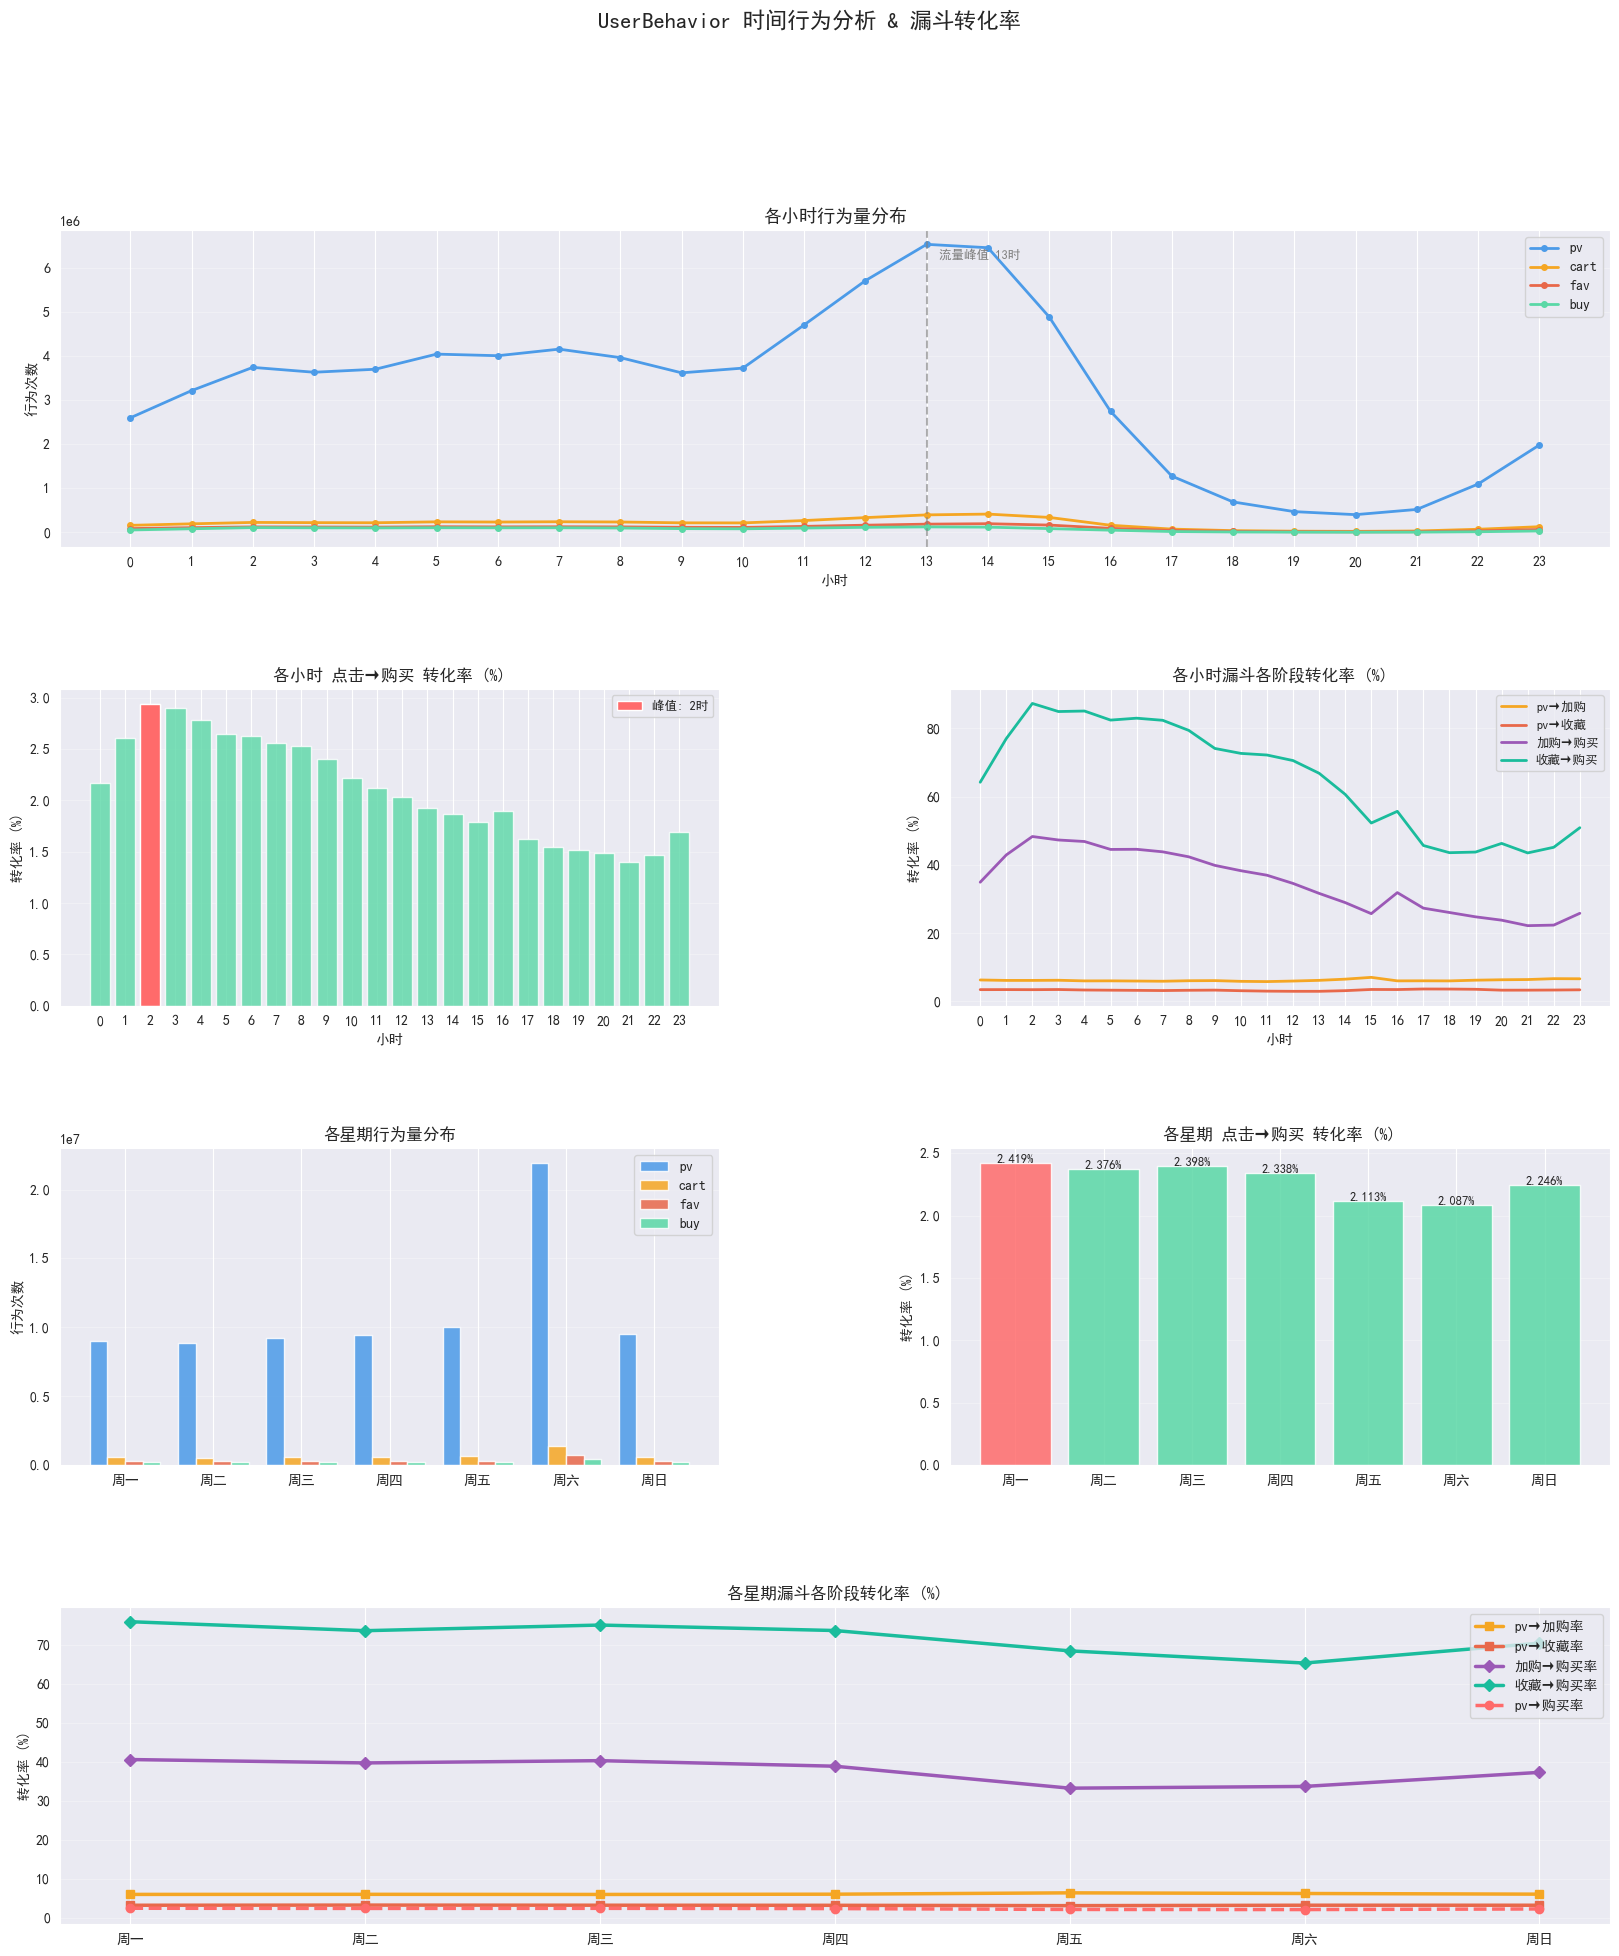

图片保存至：D:\learn\datamining\project\userbehavior\time_behavior_analysis.png


In [10]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os

plt.rcParams["font.sans-serif"] = ["SimHei", "Arial Unicode MS", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

fig = plt.figure(figsize=(20, 22))
fig.suptitle('UserBehavior 时间行为分析 & 漏斗转化率', fontsize=16, fontweight='bold', y=0.98)
gs = GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

COLORS = {'pv':'#4C9BE8','cart':'#F5A623','fav':'#E8684A','buy':'#5AD8A6'}
hours = hourly['hour']
wlabels = weekly['weekday_label']

# ── 小时行为量分布 ────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
for btype, color in COLORS.items():
    ax1.plot(hours, hourly[btype], label=btype, color=color, linewidth=2, marker='o', markersize=4)
ax1.set_title('各小时行为量分布', fontsize=13)
ax1.set_xlabel('小时')
ax1.set_ylabel('行为次数')
ax1.set_xticks(range(24))
ax1.legend()
ax1.grid(axis='y', alpha=0.3)
# 标注峰值小时
peak_hour = hourly.loc[hourly['pv'].idxmax(), 'hour']
ax1.axvline(peak_hour, color='gray', linestyle='--', alpha=0.6)
ax1.text(peak_hour + 0.2, hourly['pv'].max() * 0.95, f'流量峰值 {peak_hour}时', fontsize=9, color='gray')

# ── 小时 pv→buy 转化率 ───────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
bars = ax2.bar(hours, hourly['pv2buy_rate'], color='#5AD8A6', alpha=0.8)
ax2.set_title('各小时 点击→购买 转化率 (%)', fontsize=12)
ax2.set_xlabel('小时')
ax2.set_ylabel('转化率 (%)')
ax2.set_xticks(range(0, 24))
ax2.grid(axis='y', alpha=0.3)
# 标注最高转化率
max_idx = hourly['pv2buy_rate'].idxmax()
ax2.bar(hourly.loc[max_idx, 'hour'], hourly.loc[max_idx, 'pv2buy_rate'],
        color='#FF6B6B', label=f"峰值: {hourly.loc[max_idx,'hour']}时")
ax2.legend(fontsize=9)

# ── 小时漏斗转化率对比 ───────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(hours, hourly['pv2cart_rate'],  label='pv→加购', color='#F5A623', linewidth=2)
ax3.plot(hours, hourly['pv2fav_rate'],   label='pv→收藏', color='#E8684A', linewidth=2)
ax3.plot(hours, hourly['cart2buy_rate'], label='加购→购买', color='#9B59B6', linewidth=2)
ax3.plot(hours, hourly['fav2buy_rate'],  label='收藏→购买', color='#1ABC9C', linewidth=2)
ax3.set_title('各小时漏斗各阶段转化率 (%)', fontsize=12)
ax3.set_xlabel('小时')
ax3.set_ylabel('转化率 (%)')
ax3.set_xticks(range(0, 24))
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)

# ── 星期行为量分布 ───────────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
x = np.arange(len(wlabels))
width = 0.2
for i, (btype, color) in enumerate(COLORS.items()):
    ax4.bar(x + i * width, weekly[btype], width, label=btype, color=color, alpha=0.85)
ax4.set_title('各星期行为量分布', fontsize=12)
ax4.set_xticks(x + width * 1.5)
ax4.set_xticklabels(wlabels)
ax4.set_ylabel('行为次数')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# ── 星期 pv→buy 转化率 ──────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
bar_colors = ['#FF6B6B' if v == weekly['pv2buy_rate'].max() else '#5AD8A6'
              for v in weekly['pv2buy_rate']]
ax5.bar(wlabels, weekly['pv2buy_rate'], color=bar_colors, alpha=0.85)
ax5.set_title('各星期 点击→购买 转化率 (%)', fontsize=12)
ax5.set_ylabel('转化率 (%)')
ax5.grid(axis='y', alpha=0.3)
for i, v in enumerate(weekly['pv2buy_rate']):
    ax5.text(i, v + 0.001, f'{v:.3f}%', ha='center', fontsize=9)

# ── 星期漏斗转化率对比 ──────────────────────────────
ax6 = fig.add_subplot(gs[3, :])
ax6.plot(wlabels, weekly['pv2cart_rate'],  label='pv→加购率',  color='#F5A623', linewidth=2.5, marker='s')
ax6.plot(wlabels, weekly['pv2fav_rate'],   label='pv→收藏率',  color='#E8684A', linewidth=2.5, marker='s')
ax6.plot(wlabels, weekly['cart2buy_rate'], label='加购→购买率', color='#9B59B6', linewidth=2.5, marker='D')
ax6.plot(wlabels, weekly['fav2buy_rate'],  label='收藏→购买率', color='#1ABC9C', linewidth=2.5, marker='D')
ax6.plot(wlabels, weekly['pv2buy_rate'],   label='pv→购买率',  color='#FF6B6B', linewidth=2.5, marker='o', linestyle='--')
ax6.set_title('各星期漏斗各阶段转化率 (%)', fontsize=12)
ax6.set_ylabel('转化率 (%)')
ax6.legend(fontsize=10)
ax6.grid(axis='y', alpha=0.3)

save_path = os.path.join('..', 'time_behavior_analysis.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"图片保存至：{os.path.abspath(save_path)}")

In [11]:
#输出关键洞察摘要
# 小时维度
peak_pv_h    = hourly.loc[hourly['pv'].idxmax(), 'hour']
peak_buy_h   = hourly.loc[hourly['buy'].idxmax(), 'hour']
peak_conv_h  = hourly.loc[hourly['pv2buy_rate'].idxmax(), 'hour']
trough_pv_h  = hourly.loc[hourly['pv'].idxmin(), 'hour']

print(f"\n⏰ 小时维度")
print(f"  流量最高时段 : {peak_pv_h}时")
print(f"  购买最多时段 : {peak_buy_h}时")
print(f"  pv→buy转化率最高: {peak_conv_h}时  ({hourly.loc[hourly['pv2buy_rate'].idxmax(),'pv2buy_rate']:.4f}%)")
print(f"  流量最低时段 : {trough_pv_h}时（深夜低谷）")

# 加购/收藏→购买
best_cart_h = hourly.loc[hourly['cart2buy_rate'].idxmax(), 'hour']
best_fav_h  = hourly.loc[hourly['fav2buy_rate'].idxmax(), 'hour']
print(f"  加购→购买转化率最高: {best_cart_h}时  ({hourly.loc[hourly['cart2buy_rate'].idxmax(),'cart2buy_rate']:.4f}%)")
print(f"  收藏→购买转化率最高: {best_fav_h}时  ({hourly.loc[hourly['fav2buy_rate'].idxmax(),'fav2buy_rate']:.4f}%)")

# 星期维度
peak_pv_w   = weekly.loc[weekly['pv'].idxmax(), 'weekday_label']
peak_buy_w  = weekly.loc[weekly['buy'].idxmax(), 'weekday_label']
peak_conv_w = weekly.loc[weekly['pv2buy_rate'].idxmax(), 'weekday_label']
print(f"\n📅 星期维度")
print(f"  流量最高星期 : {peak_pv_w}")
print(f"  购买最多星期 : {peak_buy_w}")
print(f"  pv→buy转化率最高: {peak_conv_w}  ({weekly.loc[weekly['pv2buy_rate'].idxmax(),'pv2buy_rate']:.4f}%)")

# 整体漏斗
total = df['behavior_type'].value_counts()
total_pv   = total.get('pv',   0)
total_cart = total.get('cart', 0)
total_fav  = total.get('fav',  0)
total_buy  = total.get('buy',  0)
print(f"\n🔁 整体漏斗转化率")
print(f"  总 pv      : {total_pv:>12,}")
print(f"  总 加购    : {total_cart:>12,}  ({total_cart/total_pv*100:.2f}% of pv)")
print(f"  总 收藏    : {total_fav:>12,}  ({total_fav/total_pv*100:.2f}% of pv)")
print(f"  总 购买    : {total_buy:>12,}  ({total_buy/total_pv*100:.2f}% of pv)")
print(f"  加购→购买  : {total_buy/total_cart*100:.2f}%")
print(f"  收藏→购买  : {total_buy/total_fav*100:.2f}%")


⏰ 小时维度
  流量最高时段 : 13时
  购买最多时段 : 13时
  pv→buy转化率最高: 2时  (2.9378%)
  流量最低时段 : 20时（深夜低谷）
  加购→购买转化率最高: 2时  (48.2926%)
  收藏→购买转化率最高: 2时  (87.3200%)

📅 星期维度
  流量最高星期 : 周六
  购买最多星期 : 周六
  pv→buy转化率最高: 周一  (2.4193%)

🔁 整体漏斗转化率
  总 pv      :   77,887,714
  总 加购    :    4,752,175  (6.10% of pv)
  总 收藏    :    2,479,677  (3.18% of pv)
  总 购买    :    1,750,826  (2.25% of pv)
  加购→购买  : 36.84%
  收藏→购买  : 70.61%
